In [1]:
from utils.DataPreprocessing import dataloader
from loguru import logger
import os
import polars as pl
lag = 20 # number of previous time steps to consider
n_features = 15 # number of features
n_steps_out = 1 # number of output steps (how many future steps are we going to predict?)

n_epochs = 60 # 1000 epochs
learning_rate = 0.01 # 0.001 lr

hidden_size = 100 # number of features in hidden state
num_layers = 1 # number of stacked lstm layers

path = os.path.dirname(os.path.dirname(os.getcwd()))
print(path)
data = dataloader(path=path, lag=lag)

2024-04-14 17:48:27.342 | INFO     | utils.DataPreprocessing:load_csv:129 - shape: (11_103, 3)
┌───────────┬─────────────┬────────────┐
│ AVG_TEMP  ┆ AVG_TEMP_DC ┆ date       │
│ ---       ┆ ---         ┆ ---        │
│ f32       ┆ str         ┆ date       │
╞═══════════╪═════════════╪════════════╡
│ 29.299999 ┆ C           ┆ 1992-07-01 │
│ 29.200001 ┆ C           ┆ 1992-07-02 │
│ 29.6      ┆ C           ┆ 1992-07-03 │
│ 29.299999 ┆ C           ┆ 1992-07-04 │
│ 29.299999 ┆ C           ┆ 1992-07-05 │
│ …         ┆ …           ┆ …          │
│ 22.200001 ┆ C           ┆ 2022-11-26 │
│ 22.4      ┆ C           ┆ 2022-11-27 │
│ 25.4      ┆ C           ┆ 2022-11-28 │
│ 25.1      ┆ C           ┆ 2022-11-29 │
│ 22.1      ┆ C           ┆ 2022-11-30 │
└───────────┴─────────────┴────────────┘
2024-04-14 17:48:27.343 | INFO     | utils.DataPreprocessing:load_csv:131 - shape: (1, 3)
┌──────────┬─────────────┬──────┐
│ AVG_TEMP ┆ AVG_TEMP_DC ┆ date │
│ ---      ┆ ---         ┆ ---  │
│ u32      ┆ u32

/home/argonaut/programming/HK-Temperature-Forecasting


In [6]:
train = pl.DataFrame(data.train)

x = train.select(
    ["AVG_TEMP", "date"]
)

x = x.to_pandas()
x = x.set_index("date")
print(x)

             AVG_TEMP
date                 
1999-08-01  29.200001
1999-08-02  29.100000
1999-08-03  29.000000
1999-08-04  27.500000
1999-08-05  27.900000
...               ...
2018-03-27  22.400000
2018-03-28  22.000000
2018-03-29  22.200001
2018-03-30  22.799999
2018-03-31  22.799999

[6818 rows x 1 columns]


In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(x, model='additive')
trend    = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

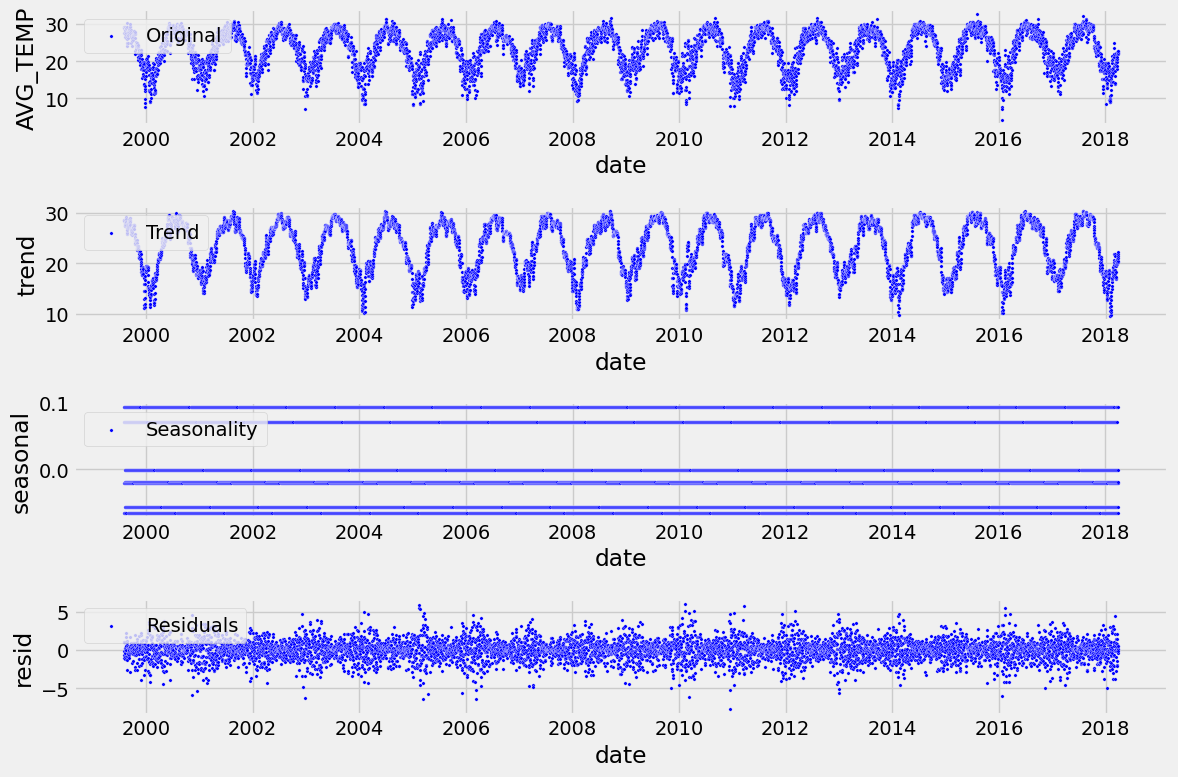

In [18]:
# Plot gathered statistics
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 8))
plt.subplot(411)
sns.scatterplot(x=x.index, y=x['AVG_TEMP'], color='blue', s=6, label='Original')
# plt.plot(x, label='Original', color='blue')
plt.legend(loc='upper left')
plt.subplot(412)
sns.scatterplot(x=trend.index, y=trend, color='blue', s=6, label='Trend')
# plt.plot(trend, label='Trend', color='blue')
plt.legend(loc='upper left')
plt.subplot(413)
sns.scatterplot(x=seasonal.index, y=seasonal, color='blue', s=6, label='Seasonality')
# plt.plot(seasonal, label='Seasonality', color='blue')
plt.legend(loc='upper left')
plt.subplot(414)
sns.scatterplot(x=residual.index, y=residual, color='blue', s=6, label='Residuals')
# plt.plot(residual, label='Residuals', color='blue')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('statistics seasonal decomposition.png')


In [24]:
trend = trend.dropna()
print(trend)

date
1999-08-04    28.614286
1999-08-05    28.614286
1999-08-06    28.514285
1999-08-07    28.257143
1999-08-08    28.114286
                ...    
2018-03-24    20.385714
2018-03-25    20.957143
2018-03-26    21.442857
2018-03-27    21.885714
2018-03-28    22.214286
Name: trend, Length: 6812, dtype: float64


In [28]:
import numpy as np
from scipy import fftpack

# Compute the one-dimensional n-point discrete Fourier Transform
x_fft = fftpack.fft(x)

Amplitude = np.abs(x_fft)
Power = Amplitude ** 2

# Compute the frequencies associated with the FFT components
sample_freq = fftpack.fftfreq(x.size, d=1)

Amp_Freq = np.array([Amplitude, sample_freq])

Amp_position = Amp_Freq[0,:].argmax()
peak_freq = Amp_Freq[1,Amp_position]

# Plot the FFT components
plt.figure(figsize=(10, 7))

plt.stem(sample_freq, Amplitude)
plt.title('X')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')


# # Plot the absolute value of the FFT components (power spectrum)
# plt.figure(figsize=(10, 7))

# plt.stem(sample_freq, np.abs(x_fft))
# plt.title('X')
# plt.xlabel('Frequency')
# plt.ylabel('Amplitude')

# plt.tight_layout()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 6818) + inhomogeneous part.

In [26]:
import numpy as np
from scipy import fftpack

# Compute the one-dimensional n-point discrete Fourier Transform
trend_fft = fftpack.fft(trend)
seasonal_fft = fftpack.fft(seasonal.dropna())
residual_fft = fftpack.fft(residual.dropna())

# Compute the frequencies associated with the FFT components
sample_freq = fftpack.fftfreq(trend.size, d=1)

# Plot the absolute value of the FFT components (power spectrum)
plt.figure(figsize=(10, 7))

plt.subplot(3, 1, 1)
plt.stem(sample_freq, np.abs(trend_fft))
plt.title('Trend')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')

plt.subplot(3, 1, 2)
plt.stem(sample_freq, np.abs(seasonal_fft))
plt.title('Seasonality')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')

plt.subplot(3, 1, 3)
plt.stem(sample_freq, np.abs(residual_fft))
plt.title('Residuals')
plt.xlabel('Frequency')
plt.ylabel('Amplitude')

plt.tight_layout()

KeyError: 'ALIGNED'